# Phase 5 — Customer Lifetime Value (BG/NBD + Gamma-Gamma)
## Retail Customer Analysis — UCI Online Retail II

**Goal of this phase:** predict the **future value** of each customer using two probabilistic
models that are the industry standard for non-contractual retail (where customers can buy
whenever they like, with no subscription):

- **BG/NBD model** — predicts *how many* future purchases a customer will make, and the
  probability they are still an active customer ("probability alive").
- **Gamma-Gamma model** — predicts the *average value* of those future purchases.

Combined, they give a **12-month Customer Lifetime Value (CLV)** estimate per customer.

**Important — these models define recency & frequency differently from RFM (Phase 4):**
- **Frequency** here = number of *repeat* purchases (total purchases minus the first). A
  one-time buyer has frequency = 0.
- **Recency** here = the age of the customer at their last purchase (time between first and
  last purchase) — *not* "days since last purchase".
- **T** = the customer's total observed age (time between first purchase and the end of data).

Because of this, we rebuild these inputs directly from the transactions rather than reusing the
RFM table.

**Data source:** `customers_clean` from PostgreSQL.


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass
import os
from pathlib import Path
from sqlalchemy import create_engine
from lifetimes import BetaGeoFitter, GammaGammaFitter

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)

def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
os.makedirs(PROCESSED_PATH, exist_ok=True)

## 2. Load Transactions

We pull customer, date, and revenue from `customers_clean`. We also collapse multiple purchases
on the **same calendar day** into a single purchase occasion — the standard convention for these
models, since two orders an hour apart represent one shopping event.

In [2]:
username = getpass.getuser()
engine = create_engine(f'postgresql+psycopg2://{username}@localhost:5432/retail_db', future=True)

df = pd.read_sql('SELECT customer_id, invoicedate, revenue FROM customers_clean', engine)
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Collapse to one purchase occasion per customer per calendar day
df['purchase_date'] = df['invoicedate'].dt.normalize()

print(f'Loaded {len(df):,} rows for {df["customer_id"].nunique():,} customers')
df.head(3)

Loaded 776,579 rows for 5,852 customers


,customer_id,invoicedate,revenue,purchase_date
0,13085,2009-12-01 07:45:00,83.40,2009-12-01
1,13085,2009-12-01 07:45:00,81.00,2009-12-01
2,13085,2009-12-01 07:45:00,81.00,2009-12-01


## 3. Build the Model Inputs (our own pandas code)

For every customer we compute the four quantities the models need, using the BG/NBD definitions
described above. Building this ourselves (rather than via a library helper) keeps it transparent
and robust to library/pandas version differences.

In [3]:
# Observation period end = the last day in the dataset
obs_end = df['purchase_date'].max()

def build_summary(transactions, period_end):
    """Return per-customer frequency, recency, T, and monetary_value (BG/NBD definitions)."""
    # One row per customer per purchase day, with that day's total spend
    daily = (transactions.groupby(['customer_id', 'purchase_date'])['revenue']
                         .sum().reset_index()
                         .sort_values(['customer_id', 'purchase_date']))

    # Per-customer first/last purchase day and number of distinct purchase days
    g = daily.groupby('customer_id')['purchase_date']
    summary = pd.DataFrame({
        'first_purchase': g.min(),
        'last_purchase':  g.max(),
        'n_purchase_days': g.nunique(),
    })

    # BG/NBD quantities, all measured in DAYS
    summary['frequency'] = summary['n_purchase_days'] - 1                       # repeat purchases
    summary['recency']   = (summary['last_purchase'] - summary['first_purchase']).dt.days
    summary['T']         = (period_end - summary['first_purchase']).dt.days

    # monetary_value = average spend across REPEAT purchase days (exclude the first day),
    # which is what the Gamma-Gamma model expects. One-time buyers get 0.
    daily['day_rank'] = daily.groupby('customer_id')['purchase_date'].rank(method='first')
    repeat_spend = (daily[daily['day_rank'] > 1]
                    .groupby('customer_id')['revenue'].mean())
    summary['monetary_value'] = repeat_spend.reindex(summary.index).fillna(0)

    return summary.reset_index()

summary = build_summary(df, obs_end)
print(f'Summary built for {len(summary):,} customers')
summary[['customer_id', 'frequency', 'recency', 'T', 'monetary_value']].head()

Summary built for 5,852 customers


,customer_id,frequency,recency,T,monetary_value
0,12346,2,322,647,"38,662.96"
1,12347,7,402,404,615.71
2,12348,4,363,438,359.31
3,12349,2,571,589,"1,305.09"
4,12350,0,0,310,0.00


In [4]:
# Sanity checks on the model inputs
print('frequency: min', summary['frequency'].min(), '| max', summary['frequency'].max())
print('recency <= T always? ', (summary['recency'] <= summary['T']).all())   # must be True
print('one-time buyers (frequency = 0):',
      f"{(summary['frequency'] == 0).sum():,} "
      f"({(summary['frequency'] == 0).mean()*100:.1f}%)")

frequency: min 0 | max 246
recency <= T always?  True
one-time buyers (frequency = 0): 1,673 (28.6%)


## 4. Validate the Model — Calibration / Holdout Test

Before trusting any prediction, we test the model honestly: fit it on an early **calibration**
period, then check how well it predicts purchases in a later **holdout** period it never saw.
This is the gold-standard check for these models.

We split at the end of February 2011: ~15 months to learn from, ~9 months to test against.

In [5]:
# Split the timeline into calibration (train) and holdout (test) windows
calibration_end = pd.Timestamp('2011-02-28')

cal_txn  = df[df['purchase_date'] <= calibration_end]
hold_txn = df[df['purchase_date'] >  calibration_end]
holdout_days = (obs_end - calibration_end).days

# Build BG/NBD inputs from the calibration window only
cal_summary = build_summary(cal_txn, calibration_end).set_index('customer_id')

# Helper: fit BG/NBD, automatically increasing the penalizer if the optimiser
# fails to converge (a known issue with this library on some datasets).
from lifetimes.utils import ConvergenceError

def fit_bgnbd(frequency, recency, T, penalizers=(0.01, 0.1, 1.0, 5.0)):
    for pen in penalizers:
        try:
            model = BetaGeoFitter(penalizer_coef=pen)
            model.fit(frequency, recency, T)
            print(f'BG/NBD converged with penalizer_coef = {pen}')
            return model
        except ConvergenceError:
            continue
    raise RuntimeError('BG/NBD failed to converge even with a large penalizer.')

# Fit BG/NBD on calibration data
bgf_cal = fit_bgnbd(cal_summary['frequency'], cal_summary['recency'], cal_summary['T'])

# Predict each customer's purchases over the holdout window length
cal_summary['predicted'] = bgf_cal.conditional_expected_number_of_purchases_up_to_time(
    holdout_days, cal_summary['frequency'], cal_summary['recency'], cal_summary['T'])

# Actual repeat-purchase days each customer made in the holdout window
actual_holdout = hold_txn.groupby('customer_id')['purchase_date'].nunique()
cal_summary['actual'] = actual_holdout.reindex(cal_summary.index).fillna(0)

print(f'Holdout window: {holdout_days} days')
print(f'Total predicted purchases: {cal_summary["predicted"].sum():,.0f}')
print(f'Total actual purchases   : {cal_summary["actual"].sum():,.0f}')
print(f'Aggregate error          : {(cal_summary["predicted"].sum()/cal_summary["actual"].sum()-1)*100:+.1f}%')

BG/NBD converged with penalizer_coef = 0.01
Holdout window: 284 days
Total predicted purchases: 11,308
Total actual purchases   : 10,455
Aggregate error          : +8.2%


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


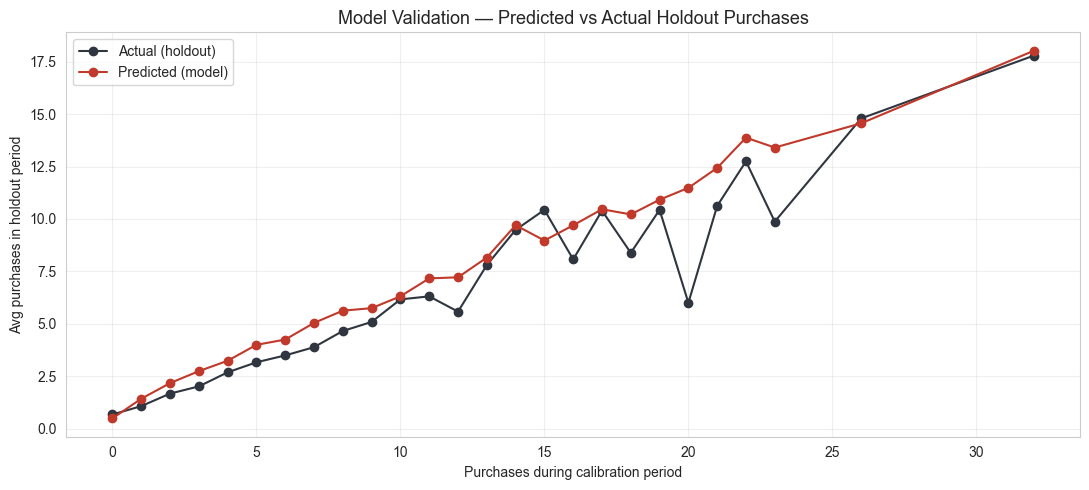

In [6]:
# Calibration plot: average actual vs predicted holdout purchases, grouped by how many
# purchases each customer made during calibration. Close lines = well-calibrated model.
by_freq = cal_summary.groupby('frequency').agg(
    actual=('actual', 'mean'), predicted=('predicted', 'mean'), customers=('actual', 'size'))
by_freq = by_freq[by_freq['customers'] >= 5]   # ignore sparse high-frequency tail

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_freq.index, by_freq['actual'],    marker='o', label='Actual (holdout)',    color='#2f3640')
ax.plot(by_freq.index, by_freq['predicted'], marker='o', label='Predicted (model)',   color='#c0392b')
ax.set_title('Model Validation — Predicted vs Actual Holdout Purchases', fontsize=13)
ax.set_xlabel('Purchases during calibration period')
ax.set_ylabel('Avg purchases in holdout period')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Fit the Final BG/NBD Model (full data)

With the model validated, we refit on the **full** dataset to make forward-looking predictions.

In [7]:
# Fit BG/NBD on the complete summary using the same robust helper
bgf = fit_bgnbd(summary['frequency'], summary['recency'], summary['T'])
print(bgf)
print()
print('Fitted parameters:')
print(bgf.summary[['coef']])

BG/NBD converged with penalizer_coef = 0.01
<lifetimes.BetaGeoFitter: fitted with 5852 subjects, a: 0.05, alpha: 62.33, b: 0.60, r: 0.66>

Fitted parameters:
       coef
r      0.66
alpha 62.33
a      0.05
b      0.60


## 6. Predict Future Purchases & Probability Alive

For each customer we estimate:
- **Expected purchases in the next 90 days** — near-term demand.
- **Probability alive** — the chance the customer is still active (has not silently churned).
  A customer who used to buy often but has gone quiet will have a low probability alive.

In [8]:
# Expected number of purchases in the next 90 days
summary['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, summary['frequency'], summary['recency'], summary['T'])

# Probability the customer is still active
summary['prob_alive'] = bgf.conditional_probability_alive(
    summary['frequency'], summary['recency'], summary['T'])

summary[['customer_id', 'frequency', 'recency', 'T',
         'predicted_purchases_90d', 'prob_alive']].head()

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,customer_id,frequency,recency,T,predicted_purchases_90d,prob_alive
0,12346,2,322,647,0.29,0.87
1,12347,7,402,404,1.46,0.99
2,12348,4,363,438,0.81,0.97
3,12349,2,571,589,0.35,0.97
4,12350,0,0,310,0.16,1.00


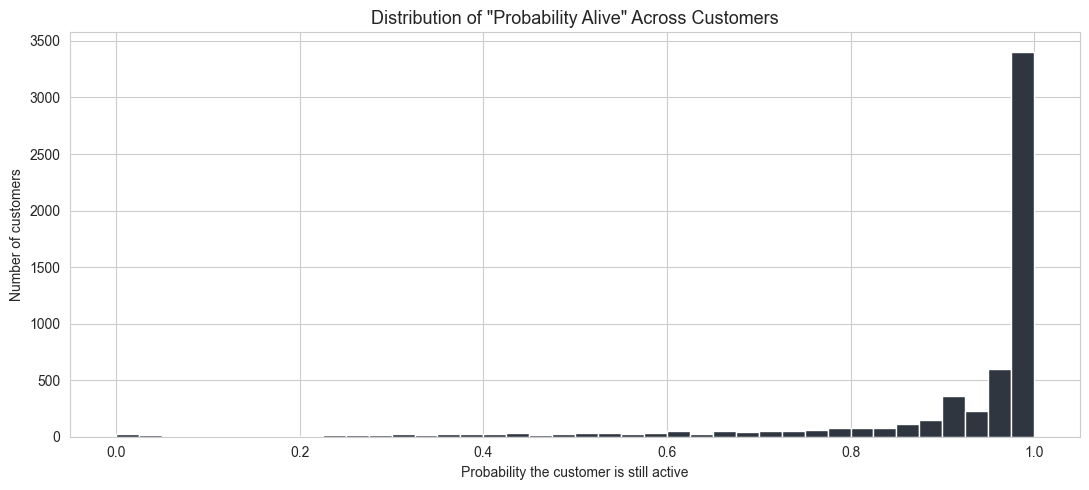

In [9]:
# Distribution of probability alive across the customer base
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(summary['prob_alive'], bins=40, color='#2f3640', edgecolor='white')
ax.set_title('Distribution of "Probability Alive" Across Customers', fontsize=13)
ax.set_xlabel('Probability the customer is still active')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

## 7. Gamma-Gamma Model — Predicting Spend

The Gamma-Gamma model predicts each customer's average purchase value. It has one key
assumption: **purchase frequency and spend must be roughly uncorrelated.** We check that first.
It also requires repeat purchases, so it is fit only on customers with frequency > 0.

In [10]:
# Gamma-Gamma needs repeat customers with positive spend
repeat = summary[(summary['frequency'] > 0) & (summary['monetary_value'] > 0)].copy()

# Assumption check: correlation between frequency and monetary value should be near zero
corr = repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'Frequency vs monetary correlation: {corr:.3f}  (should be close to 0)')
print(f'Repeat customers used for Gamma-Gamma: {len(repeat):,}')

Frequency vs monetary correlation: 0.020  (should be close to 0)
Repeat customers used for Gamma-Gamma: 4,179


In [11]:
# Fit Gamma-Gamma on repeat customers
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat['frequency'], repeat['monetary_value'])

# Expected average profit per transaction for each repeat customer
repeat['exp_avg_value'] = ggf.conditional_expected_average_profit(
    repeat['frequency'], repeat['monetary_value'])

print('Model-estimated average transaction value: '
      f"£{repeat['exp_avg_value'].mean():,.2f}")
print('Actual average transaction value         : '
      f"£{repeat['monetary_value'].mean():,.2f}")

Model-estimated average transaction value: £483.68
Actual average transaction value         : £442.26


## 8. Compute 12-Month CLV

Finally we combine both models into a **12-month customer lifetime value** for every repeat
customer — the expected future profit, discounted slightly for the time value of money.

In [12]:
# 12-month CLV using both fitted models. freq='D' tells it our time unit is days.
repeat['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    repeat['frequency'], repeat['recency'], repeat['T'],
    repeat['monetary_value'],
    time=12,             # months ahead
    freq='D',            # recency / T are in days
    discount_rate=0.01   # ~monthly discount rate
)

print('12-month CLV summary (repeat customers):')
print(repeat['clv_12m'].describe())

12-month CLV summary (repeat customers):
count     4,179.00
mean      2,010.83
std       9,484.87
min           0.00
25%         321.20
50%         772.20
75%       1,784.42
max     383,585.42
Name: clv_12m, dtype: float64


In [13]:
# Top 10 customers by predicted 12-month value
(repeat.sort_values('clv_12m', ascending=False)
       [['customer_id', 'frequency', 'recency', 'T', 'prob_alive', 'clv_12m']]
       .head(10))

,customer_id,frequency,recency,T,prob_alive,clv_12m
4037,16446,1,205,205,0.93,"383,585.42"
5666,18102,66,738,738,1.00,"244,814.21"
2262,14646,90,736,737,1.00,"219,995.27"
5026,17450,30,430,438,1.00,"140,259.24"
1778,14156,116,729,738,1.00,"126,978.36"
2520,14911,246,737,738,1.00,"113,877.57"
1720,14096,16,97,101,1.00,"111,610.09"
67,12415,18,503,527,0.99,"83,459.52"
1321,13694,82,732,735,1.00,"81,796.10"
5085,17511,50,735,737,1.00,"71,852.32"


## 9. Reliability of Individual CLV Estimates

The ranking above exposes a known limitation of the Gamma-Gamma model: for customers with very
few repeat purchases, the predicted spend is highly unstable. The top customer (ID 16446) has
only **one** repeat purchase, yet shows the highest CLV of all &mdash; the model has nothing to
average against and simply echoes that single (likely wholesale) order.

Individual CLV is therefore only trustworthy for customers with enough repeat history. Below we
(a) quantify how skewed the raw estimates are and how many top spots are low-frequency artifacts,
and (b) produce a more reliable top-customer ranking restricted to customers with **3 or more
repeat purchases**. Aggregate and segment-level CLV (next section) stay robust, because averaging
over many customers cancels out these individual extremes.

In [14]:
# Quantify the skew and the low-frequency reliability risk
print('CLV distribution (repeat customers):')
print(f"  median : GBP {repeat['clv_12m'].median():,.0f}")
print(f"  mean   : GBP {repeat['clv_12m'].mean():,.0f}")
print(f"  max    : GBP {repeat['clv_12m'].max():,.0f}")
print()

# How many of the top 50 CLV customers are low-frequency (<= 1 repeat) artifacts?
top50 = repeat.nlargest(50, 'clv_12m')
n_lowfreq = int(top50['frequency'].le(1).sum())
print(f'Among the top 50 by CLV, customers with only 1 repeat purchase: {n_lowfreq}')

CLV distribution (repeat customers):
  median : GBP 772
  mean   : GBP 2,011
  max    : GBP 383,585

Among the top 50 by CLV, customers with only 1 repeat purchase: 3


In [15]:
# Reliable ranking: restrict to customers with enough repeat history (frequency >= 3)
reliable = repeat[repeat['frequency'] >= 3]
print(f'Reliable subset (frequency >= 3): {len(reliable):,} customers')

(reliable.sort_values('clv_12m', ascending=False)
         [['customer_id', 'frequency', 'recency', 'T', 'prob_alive', 'clv_12m']]
         .head(10))

Reliable subset (frequency >= 3): 2,530 customers


,customer_id,frequency,recency,T,prob_alive,clv_12m
5666,18102,66,738,738,1.00,"244,814.21"
2262,14646,90,736,737,1.00,"219,995.27"
5026,17450,30,430,438,1.00,"140,259.24"
1778,14156,116,729,738,1.00,"126,978.36"
2520,14911,246,737,738,1.00,"113,877.57"
1720,14096,16,97,101,1.00,"111,610.09"
67,12415,18,503,527,0.99,"83,459.52"
1321,13694,82,732,735,1.00,"81,796.10"
5085,17511,50,735,737,1.00,"71,852.32"
4271,16684,34,728,732,1.00,"62,892.84"


## 10. Tie CLV Back to the RFM Segments (Phase 4)

Joining predicted CLV onto the named segments shows that the forward-looking value model agrees
with the behavioural segmentation — Champions should carry by far the highest predicted value.

In [16]:
# Bring in the segment labels created in Phase 4
segments = pd.read_sql('SELECT customer_id, segment FROM rfm_segments', engine)

clv_by_seg = (repeat.merge(segments, on='customer_id', how='left')
                    .groupby('segment')
                    .agg(customers=('customer_id', 'count'),
                         avg_clv_12m=('clv_12m', 'mean'),
                         total_clv_12m=('clv_12m', 'sum'))
                    .sort_values('total_clv_12m', ascending=False)
                    .round(2))
clv_by_seg

,customers,avg_clv_12m,total_clv_12m
segment,,,
Champions,825,"5,244.48","4,326,698.10"
Loyal Customers,1157,"1,929.83","2,232,809.28"
Potential Loyalists,632,"1,729.00","1,092,724.93"
At Risk,741,489.92,"363,029.48"
Need Attention,265,695.55,"184,321.51"
Hibernating,354,219.34,"77,646.38"
About to Sleep,133,565.99,"75,276.32"
Cannot Lose Them,72,705.15,"50,771.10"


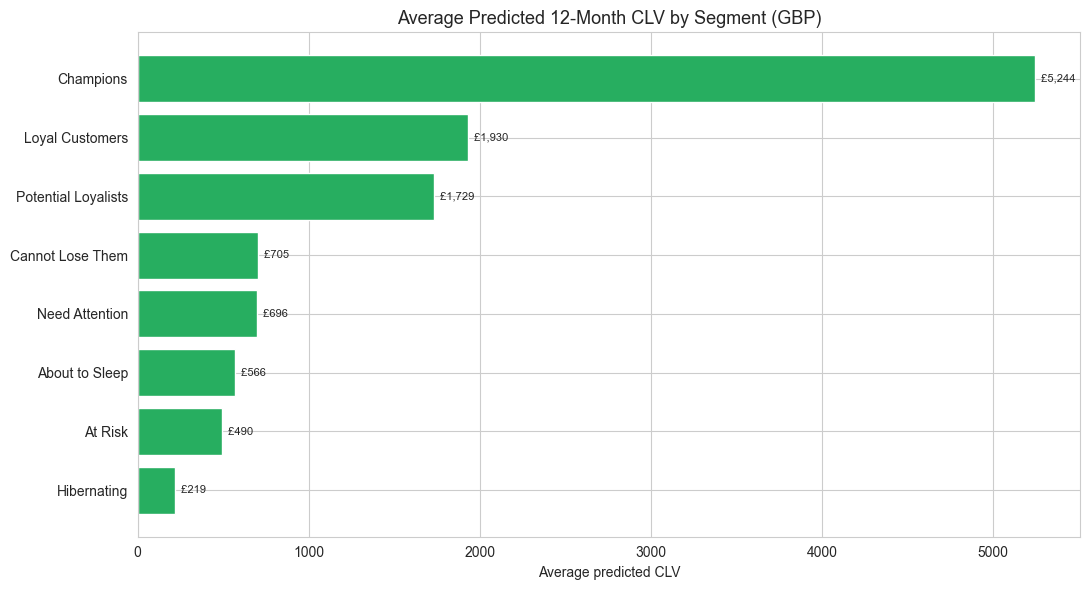

In [17]:
# Average predicted 12-month CLV by segment
order = clv_by_seg.sort_values('avg_clv_12m')
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(order.index, order['avg_clv_12m'], color='#27ae60')
ax.set_title('Average Predicted 12-Month CLV by Segment (GBP)', fontsize=13)
ax.set_xlabel('Average predicted CLV')
for i, v in enumerate(order['avg_clv_12m']):
    ax.text(v, i, f'  £{v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 11. Save Results

Save the per-customer CLV predictions to CSV and PostgreSQL for the dashboard phase.

In [18]:
# Assemble the customer-level CLV output
clv_output = summary.merge(
    repeat[['customer_id', 'exp_avg_value', 'clv_12m']], on='customer_id', how='left')

# One-time buyers have no Gamma-Gamma value; fill their CLV with 0 for completeness
clv_output['clv_12m'] = clv_output['clv_12m'].fillna(0)
clv_output['exp_avg_value'] = clv_output['exp_avg_value'].fillna(0)

clv_output.to_csv(PROCESSED_PATH + 'clv_predictions.csv', index=False)
clv_output.to_sql('clv_predictions', engine, if_exists='replace', index=False,
                  chunksize=5000, method='multi')
print(f'Saved clv_predictions: {len(clv_output):,} customers')

Saved clv_predictions: 5,852 customers


## 12. Phase 5 Summary

Every customer now has a predicted probability of being active, an expected number of near-term
purchases, and a 12-month lifetime value — validated against a holdout period before use. The
CLV-by-segment view confirms the value model and the RFM segmentation tell the same story.

**Next — Phase 6: Market Basket Analysis.** We switch from *who* the customers are to *what they
buy together*, using association-rule mining (Apriori / FP-Growth) on the full transaction set to
surface product affinities for cross-selling and bundling.
